<a href="https://colab.research.google.com/github/parthsharmaww-ai/Stock-Direction-Predictor/blob/main/notebooks/02_data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 2 — Data Collection & Exploration

In this notebook we:
1. Download 5 years of Nifty 50 daily data
2. Clean and flatten the dataframe
3. Explore the data visually
4. Save it for use in Stage 3

In [1]:
!pip install yfinance pandas numpy matplotlib seaborn --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful ✓")

All imports successful ✓


In [2]:
# Download full dataset
df = yf.download("^NSEI", start="2019-01-01", end="2024-12-31", auto_adjust=True)

# Flatten multi-level columns
df.columns = df.columns.get_level_values(0)

# Reset index so Date becomes a regular column
df = df.reset_index()

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nDate range:", df["Date"].min(), "to", df["Date"].max())

[*********************100%***********************]  1 of 1 completed

Shape: (1477, 6)

First 5 rows:
Price       Date         Close          High           Low          Open  \
0     2019-01-02  10792.500000  10895.349609  10735.049805  10868.849609   
1     2019-01-03  10672.250000  10814.049805  10661.250000  10796.799805   
2     2019-01-04  10727.349609  10741.049805  10628.650391  10699.700195   
3     2019-01-07  10771.799805  10835.950195  10750.150391  10804.849609   
4     2019-01-08  10802.150391  10818.450195  10733.250000  10786.250000   

Price  Volume  
0      309700  
1      286200  
2      296600  
3      269400  
4      277700  

Column names: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Date range: 2019-01-02 00:00:00 to 2024-12-30 00:00:00


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values per column:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Data types:
Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


In [4]:
# Drop rows with any missing values
df = df.dropna()

print("Shape after cleaning:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())

Shape after cleaning: (1477, 6)
Missing values remaining: 0


## Cleaning notes
- auto_adjust=True used so prices are adjusted for splits/dividends
- Multi-level columns flattened
- Dropped any rows with missing values
- Final dataset shape recorded above

In [5]:
print("Basic statistics:")
print(df.describe().round(2))

Basic statistics:
Price                           Date     Close      High       Low      Open  \
count                           1477   1477.00   1477.00   1477.00   1477.00   
mean   2022-01-01 05:25:37.982396928  16372.56  16461.70  16278.22  16383.65   
min              2019-01-02 00:00:00   7610.25   8036.95   7511.10   7735.15   
25%              2020-07-09 00:00:00  11914.20  11969.25  11850.25  11928.80   
50%              2021-12-31 00:00:00  16953.95  17091.00  16828.35  16947.50   
75%              2023-06-28 00:00:00  18857.25  19011.25  18837.85  18908.15   
max              2024-12-30 00:00:00  26216.05  26277.35  26151.40  26248.25   
std                              NaN   4411.44   4419.36   4402.78   4411.15   

Price      Volume  
count     1477.00  
mean    402483.89  
min          0.00  
25%     257700.00  
50%     333600.00  
75%     514800.00  
max    1811000.00  
std     207804.80  


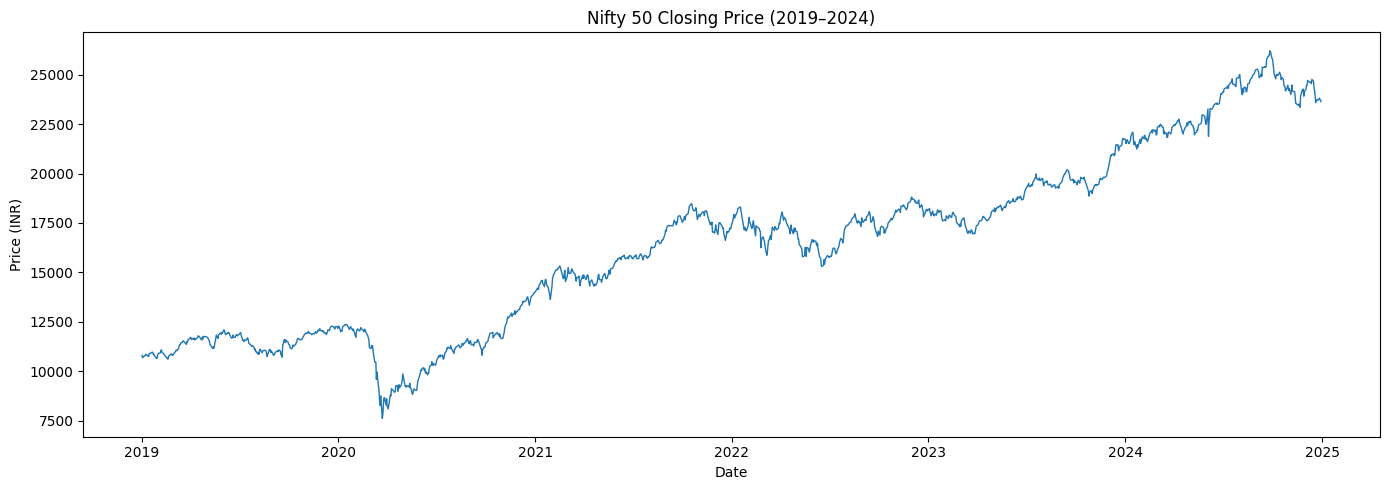

Chart saved ✓


In [9]:
import os

# Create reports folder in current Colab session
os.makedirs("reports", exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Close"], color="#1f77b4", linewidth=1)
plt.title("Nifty 50 Closing Price (2019–2024)")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.savefig("reports/nifty50_closing_price.png", dpi=150)
plt.show()
print("Chart saved ✓")

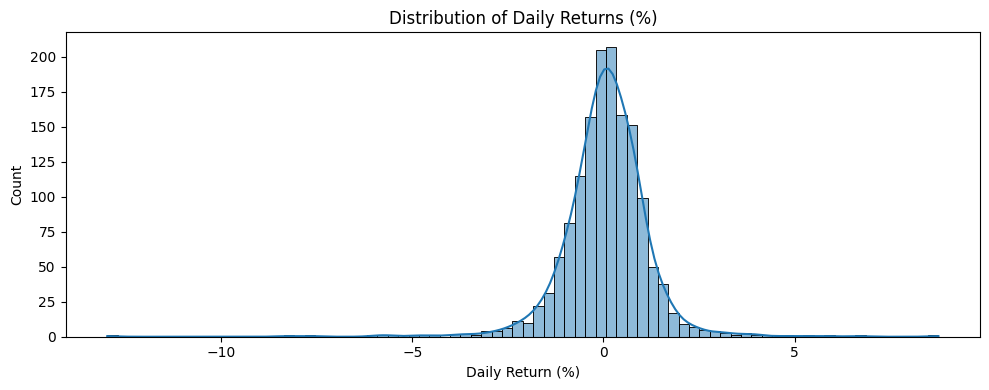

Chart saved ✓


In [11]:
# Calculate daily returns
df["Daily_Return"] = df["Close"].pct_change() * 100

plt.figure(figsize=(10, 4))
sns.histplot(df["Daily_Return"].dropna(), bins=80, kde=True, color="#1f77b4")
plt.title("Distribution of Daily Returns (%)")
plt.xlabel("Daily Return (%)")
plt.tight_layout()
plt.savefig("reports/daily_returns_distribution.png", dpi=150)
plt.show()
print("Chart saved ✓")

In [12]:
# How often does the market go up vs down?
df["Tomorrow_Direction"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

up_days = df["Tomorrow_Direction"].sum()
down_days = (df["Tomorrow_Direction"] == 0).sum()
total = up_days + down_days

print(f"Up days:   {up_days} ({up_days/total*100:.1f}%)")
print(f"Down days: {down_days} ({down_days/total*100:.1f}%)")
print(f"\nBaseline accuracy (always predict up): {up_days/total*100:.1f}%")

Up days:   812 (55.0%)
Down days: 665 (45.0%)

Baseline accuracy (always predict up): 55.0%


## Key finding from Stage 2

- Dataset: 1477 trading days (2019–2024)
- Up days: 812 (55.0%)
- Down days: 665 (45.0%)
- Baseline accuracy: 55.0% (always predict "up")
- Any model must exceed 55% to be meaningful

In [15]:
import os

# Create data folder
os.makedirs("data", exist_ok=True)

# Save CSV
df.to_csv("data/nifty50_raw.csv", index=False)
print("Data saved to data/nifty50_raw.csv ✓")
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())

Data saved to data/nifty50_raw.csv ✓
Final shape: (1477, 8)
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Tomorrow_Direction']
